In [ ]:
import kagglehub

# Download latest version https://www.kaggle.com/datasets/mateuscco/toy-network-datasets
path = kagglehub.dataset_download("mateuscco/toy-network-datasets")

print("Path to dataset files:", path)

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# --- chemin vers ton fichier .net ---
path = 'data/graphs/Ring25.net'   

# Charger le graphe Pajek
G_raw = nx.read_pajek(path)  
G_raw


In [2]:
# NetworkX retourne souvent un MultiGraph/DiGraph depuis Pajek.
#    Pour simplifier l'usage (viz, mesures), on convertit en Graph/DiGraph “simple”.

if G_raw.is_directed():
    G = nx.DiGraph(G_raw)   # ou nx.DiGraph(G_raw, as_view=False) selon version
else:
    G = nx.Graph(G_raw)

# Si le fichier contient des poids, ils seront dans l'attribut "weight"
print(type(G), "directed?" , G.is_directed())
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

# Afficher quelques noeuds/attributs
sample_nodes = list(G.nodes())[:5]
print("Sample nodes:", sample_nodes)
for n in sample_nodes:
    print(n, G.nodes[n])


<class 'networkx.classes.graph.Graph'> directed? False
Nodes: 25 Edges: 50
Sample nodes: ['1', '2', '3', '4', '5']
1 {'id': '1', 'x': 0.1, 'y': 0.5, 'shape': '0.5000'}
2 {'id': '2', 'x': 0.1126, 'y': 0.4005, 'shape': '0.5000'}
3 {'id': '3', 'x': 0.1495, 'y': 0.3073, 'shape': '0.5000'}
4 {'id': '4', 'x': 0.2084, 'y': 0.2262, 'shape': '0.5000'}
5 {'id': '5', 'x': 0.2857, 'y': 0.1623, 'shape': '0.5000'}


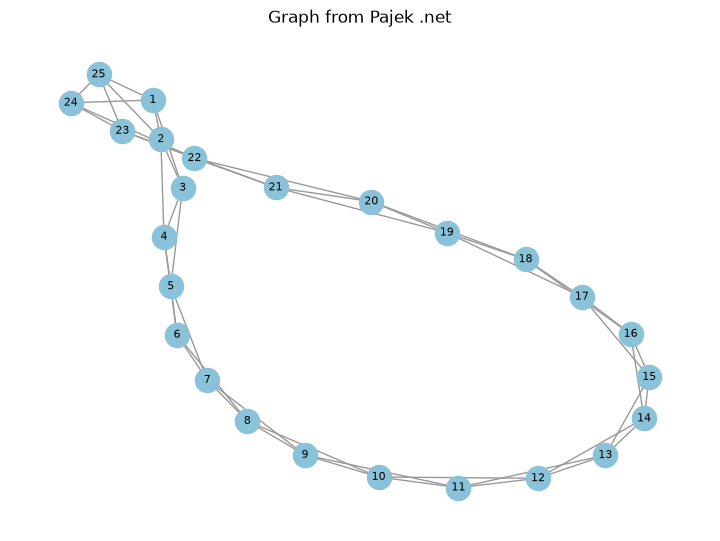

In [3]:
# 4) Visualisation simple
plt.figure(figsize=(7, 5))
pos = nx.spring_layout(G, seed=42)  # layout force-directed
nx.draw(G, pos,
        with_labels=True,
        node_size=300,
        font_size=8,
        node_color="#89C2D9",
        edge_color="#999999")
plt.title("Graph from Pajek .net")
plt.show()


Connected components: 1
Top 5 nodes by degree: [('1', 4), ('2', 4), ('3', 4), ('4', 4), ('5', 4)]


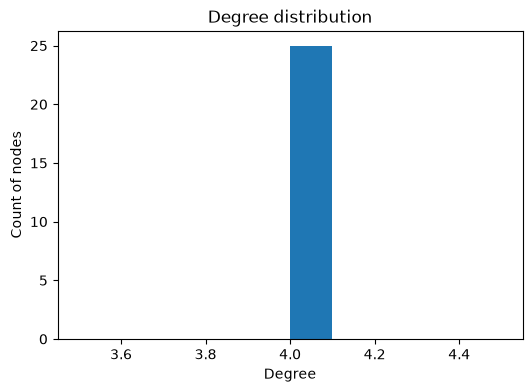

In [4]:
# 5) Mesures de base
print("Connected components:", nx.number_connected_components(G) if not G.is_directed() else "N/A (directed)")

deg = dict(G.degree())
print("Top 5 nodes by degree:", sorted(deg.items(), key=lambda x: x[1], reverse=True)[:5])

# Distribution des degrés
plt.figure(figsize=(6,4))
plt.hist(list(deg.values()), bins=10)
plt.xlabel("Degree"); plt.ylabel("Count of nodes"); plt.title("Degree distribution")
plt.show()


In [5]:
import ipycytoscape

G = nx.Graph(G_raw)

cyto_widget = ipycytoscape.CytoscapeWidget()
cyto_widget.graph.add_graph_from_networkx(G)
cyto_widget


CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'css': {'background-c…